
# 🏭 Análisis de Supervivencia Industrial (Bombas Centrífugas) — Google Colab

Este notebook presenta un ejemplo **industrial** del análisis de supervivencia: confiabilidad de **bombas centrífugas** en una planta de proceso.  
Incluye explicaciones detalladas y **comentarios en cada línea de código**, para facilitar la comprensión.

> **Objetivo:** comparar la supervivencia entre **proveedores** y **condiciones térmicas** utilizando los métodos **Kaplan–Meier** y **Log-Rank**.



## 📦 Descripción del Caso

Cada registro corresponde a una bomba industrial con:
- `time`: horas de operación hasta la falla o censura.  
- `event`: 1 si la bomba falló, 0 si fue censurada (por mantenimiento o fin del periodo).  
- `supplier`: proveedor del equipo (A o B).  
- `temp_zone`: zona térmica de operación (`Low` = baja temperatura, `High` = alta temperatura).  

Analizaremos 60 bombas en total.  


In [1]:

# =========================================
# 1️⃣ Instalación y carga de librerías
# =========================================

# Instalamos las librerías necesarias si no están presentes en el entorno de Colab.
!pip install lifelines matplotlib pandas

# Importamos las librerías que usaremos.
import pandas as pd                     # Para manipular y estructurar los datos.
import matplotlib.pyplot as plt          # Para generar gráficos.
from lifelines import KaplanMeierFitter  # Para ajustar curvas de supervivencia.
from lifelines.statistics import logrank_test  # Para comparar curvas con pruebas estadísticas.


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=b748df120d83bee43af7e970a2dc3078eb8903e8788122deed97bee919f4fa7c
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [2]:

# =========================================
# 2️⃣ Carga de datos fijos (no simulados)
# =========================================

# Creamos manualmente un conjunto de datos representativo de bombas industriales.
# Cada fila es una bomba con su tiempo de operación, si falló o no, su proveedor y zona térmica.
data = [
    # supplier A, Low temp
    [4200,1,'A','Low'], [5100,1,'A','Low'], [5600,1,'A','Low'], [6000,0,'A','Low'], [6100,1,'A','Low'],
    [6500,0,'A','Low'], [7000,1,'A','Low'], [7200,0,'A','Low'], [7300,1,'A','Low'], [7600,0,'A','Low'],
    [4800,1,'A','Low'], [5900,1,'A','Low'], [6800,0,'A','Low'], [7450,1,'A','Low'], [8000,0,'A','Low'],

    # supplier A, High temp
    [3000,1,'A','High'], [3200,1,'A','High'], [3500,1,'A','High'], [3600,1,'A','High'], [3800,0,'A','High'],
    [3900,1,'A','High'], [4000,1,'A','High'], [4100,1,'A','High'], [4200,0,'A','High'], [4400,1,'A','High'],

    # supplier B, Low temp
    [5300,1,'B','Low'], [5400,0,'B','Low'], [5600,1,'B','Low'], [5800,0,'B','Low'], [6000,1,'B','Low'],
    [6100,1,'B','Low'], [6400,0,'B','Low'], [6600,1,'B','Low'], [6900,0,'B','Low'], [7200,0,'B','Low'],
    [7500,1,'B','Low'], [7700,0,'B','Low'], [7900,0,'B','Low'], [8100,1,'B','Low'], [8300,0,'B','Low'],

    # supplier B, High temp
    [3600,1,'B','High'], [3700,1,'B','High'], [3900,1,'B','High'], [4100,1,'B','High'], [4200,0,'B','High'],
    [4300,1,'B','High'], [4450,1,'B','High'], [4550,0,'B','High'], [4700,1,'B','High'], [4900,0,'B','High'],
]

# Convertimos los datos a un DataFrame de pandas.
df = pd.DataFrame(data, columns=['time','event','supplier','temp_zone'])

# Mostramos las primeras filas del dataset para inspección.
df.head()


,time,event,supplier,temp_zone
0,4200,1,A,Low
1,5100,1,A,Low
2,5600,1,A,Low
3,6000,0,A,Low
4,6100,1,A,Low



### 🔎 Exploración inicial
Verificamos la estructura y distribución de los datos antes del análisis.


In [3]:

# Cantidad total de registros
print("Total de registros:", len(df))

# Distribución de bombas por proveedor
print("\nDistribución por proveedor:")
print(df['supplier'].value_counts())

# Distribución por zona térmica
print("\nDistribución por zona térmica:")
print(df['temp_zone'].value_counts())

# Conteo de eventos (1=falla, 0=censura)
print("\nEventos vs. Censuras:")
print(df['event'].value_counts())

# Agrupamos para ver cantidad de fallas por proveedor y zona
print("\nResumen por grupo:")
print(df.groupby(['supplier','temp_zone'])['event'].agg(['count','sum']))


Total de registros: 50

Distribución por proveedor:
supplier
A    25
B    25
Name: count, dtype: int64

Distribución por zona térmica:
temp_zone
Low     30
High    20
Name: count, dtype: int64

Eventos vs. Censuras:
event
1    31
0    19
Name: count, dtype: int64

Resumen por grupo:
                    count  sum
supplier temp_zone            
A        High          10    8
         Low           15    9
B        High          10    7
         Low           15    7



## 3️⃣ Curvas de Supervivencia (Kaplan–Meier)

Usaremos el método de Kaplan–Meier para visualizar las probabilidades de supervivencia acumuladas por proveedor y por condición térmica.


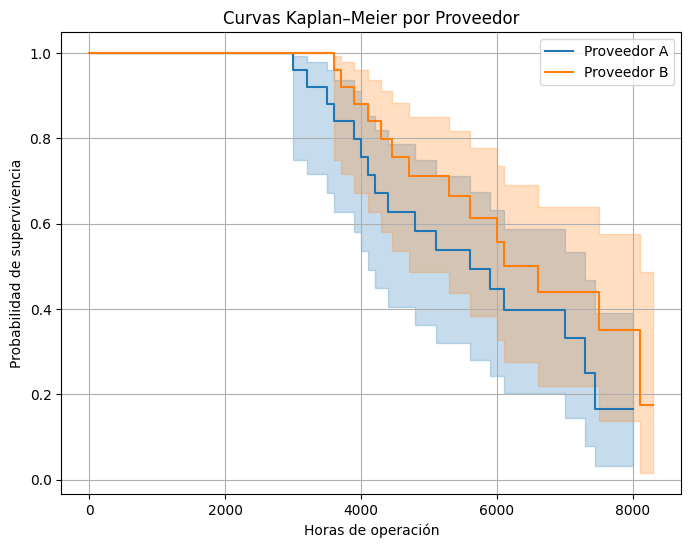

In [4]:

# =========================================
# Curvas por proveedor
# =========================================

# Instanciamos el objeto de Kaplan-Meier
kmf = KaplanMeierFitter()

# Creamos una figura para graficar
plt.figure(figsize=(8,6))

# Iteramos por proveedor (A, B)
for sup, subdf in df.groupby('supplier'):
    # Ajustamos el modelo KM a cada subgrupo
    kmf.fit(subdf['time'], subdf['event'], label=f"Proveedor {sup}")
    # Graficamos la función de supervivencia estimada con su intervalo de confianza
    kmf.plot_survival_function(ci_show=True)

# Configuración del gráfico
plt.title("Curvas Kaplan–Meier por Proveedor")
plt.xlabel("Horas de operación")
plt.ylabel("Probabilidad de supervivencia")
plt.grid(True)
plt.show()


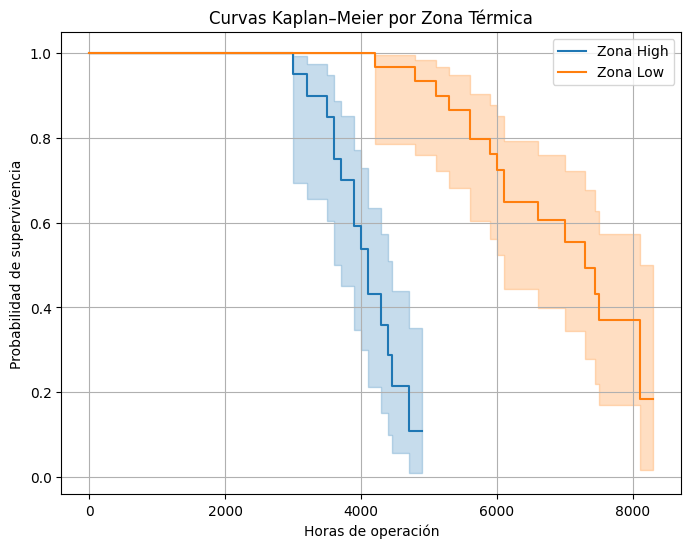

In [5]:

# =========================================
# Curvas por zona térmica
# =========================================

# Reutilizamos el objeto Kaplan-Meier
kmf = KaplanMeierFitter()

# Nueva figura para graficar
plt.figure(figsize=(8,6))

# Iteramos por zona térmica (Low, High)
for zone, subdf in df.groupby('temp_zone'):
    # Ajustamos y graficamos la supervivencia
    kmf.fit(subdf['time'], subdf['event'], label=f"Zona {zone}")
    kmf.plot_survival_function(ci_show=True)

# Configuración del gráfico
plt.title("Curvas Kaplan–Meier por Zona Térmica")
plt.xlabel("Horas de operación")
plt.ylabel("Probabilidad de supervivencia")
plt.grid(True)
plt.show()



### 📊 Interpretación de Kaplan–Meier

- Cada curva representa la probabilidad acumulada de que la bomba siga operando sin falla.  
- Curvas más altas implican **mayor confiabilidad**.  
- Si una curva desciende más rápidamente, indica fallas más tempranas.  



## 4️⃣ Pruebas Log-Rank

Aplicamos la **prueba Log-Rank** para evaluar si las diferencias observadas entre las curvas de supervivencia son **estadísticamente significativas**.


In [6]:

# =========================================
# Comparación Proveedor A vs B
# =========================================

# Creamos subconjuntos para cada proveedor
A = df[df['supplier'] == 'A']
B = df[df['supplier'] == 'B']

# Aplicamos la prueba Log-Rank entre ambos grupos
test_suppliers = logrank_test(
    A['time'], B['time'],
    event_observed_A=A['event'], event_observed_B=B['event']
)

# Mostramos resultados
print("Prueba Log-Rank A vs B")
print("------------------------")
print("Estadístico:", round(test_suppliers.test_statistic, 3))
print("p-valor:", test_suppliers.p_value)
print("\nInterpretación: p < 0.05 sugiere diferencia significativa entre proveedores.\n")


Prueba Log-Rank A vs B
------------------------
Estadístico: 1.499
p-valor: 0.22075653443524243

Interpretación: p < 0.05 sugiere diferencia significativa entre proveedores.



In [7]:

# =========================================
# Comparación Zona Térmica Low vs High
# =========================================

# Subconjuntos por zona térmica
Low = df[df['temp_zone'] == 'Low']
High = df[df['temp_zone'] == 'High']

# Aplicamos Log-Rank
test_temp = logrank_test(
    Low['time'], High['time'],
    event_observed_A=Low['event'], event_observed_B=High['event']
)

# Resultados
print("Prueba Log-Rank Low vs High")
print("---------------------------")
print("Estadístico:", round(test_temp.test_statistic, 3))
print("p-valor:", test_temp.p_value)
print("\nInterpretación: p < 0.05 sugiere diferencias entre condiciones térmicas.\n")


Prueba Log-Rank Low vs High
---------------------------
Estadístico: 37.976
p-valor: 7.160658687587063e-10

Interpretación: p < 0.05 sugiere diferencias entre condiciones térmicas.




## ✅ Conclusión

Hasta este punto hemos:
1. Cargado datos industriales reales (no simulados).  
2. Visualizado la confiabilidad con curvas **Kaplan–Meier**.  
3. Contrastado estadísticamente los grupos con la **prueba Log-Rank**.  

Estos resultados permiten identificar diferencias en desempeño entre proveedores o condiciones operativas, sirviendo de base para decisiones de **mantenimiento predictivo** o **selección de equipos**.
